## Dataset Credit
* **Dataset Name:** Student Performance Dataset
* **Source / Link:** [https://www.kaggle.com/datasets/devansodariya/student-performance-data]

# LAB1: Dataset Exploration

In [3]:
import pandas as pd
import numpy as np

# 1. Load Dataset
df = pd.read_csv('student_data.csv')

# 2. Display Shape
print("--- Data Shape ---")
print(df.shape)
print()

# 3. Display Data Types
print("--- Data Types ---")
print(df.dtypes)
print()

# แสดงหน้าตาข้อมูล 5 แถวแรก
df.head()

--- Data Shape ---
(395, 33)

--- Data Types ---
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object



,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
# 4. Display Summary Statistics (ดูสถิติเบื้องต้น เช่น ค่าเฉลี่ย, มิน-แม็กซ์ ของพวกคอลัมน์ตัวเลข)
print("--- Summary Statistics ---")
print(df.describe())
print("\n" + "="*50 + "\n")

# 5. Display Missing Values (เช็กว่ามีคอลัมน์ไหนข้อมูลขาดหายไปไหม)
print("--- Missing Values Check ---")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")

# 6. Display Duplicate Records (เช็กจำนวนข้อมูลที่ซ้ำกัน)
print("--- Duplicate Records Check ---")
print(f"จำนวนแถวที่ซ้ำกันทั้งหมด: {df.duplicated().sum()} แถว")
print("\n" + "="*50 + "\n")

# 7. Display Class Distribution (ตัวอย่างเช่น ดูสัดส่วนเพศของนักเรียนในข้อมูลนี้)
print("--- Class Distribution (Gender) ---")
print(df['sex'].value_counts())

--- Summary Statistics ---
              age        Medu        Fedu  traveltime   studytime    failures  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean    16.696203    2.749367    2.521519    1.448101    2.035443    0.334177   
std      1.276043    1.094735    1.088201    0.697505    0.839240    0.743651   
min     15.000000    0.000000    0.000000    1.000000    1.000000    0.000000   
25%     16.000000    2.000000    2.000000    1.000000    1.000000    0.000000   
50%     17.000000    3.000000    2.000000    1.000000    2.000000    0.000000   
75%     18.000000    4.000000    3.000000    2.000000    2.000000    0.000000   
max     22.000000    4.000000    4.000000    4.000000    4.000000    3.000000   

           famrel    freetime       goout        Dalc        Walc      health  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean     3.944304    3.235443    3.108861    1.481013    2.291139    3.554430   


## LAB2: Data Visualization

Matplotlib is building the font cache; this may take a moment.


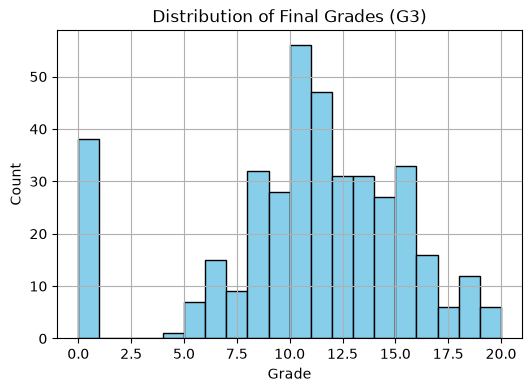

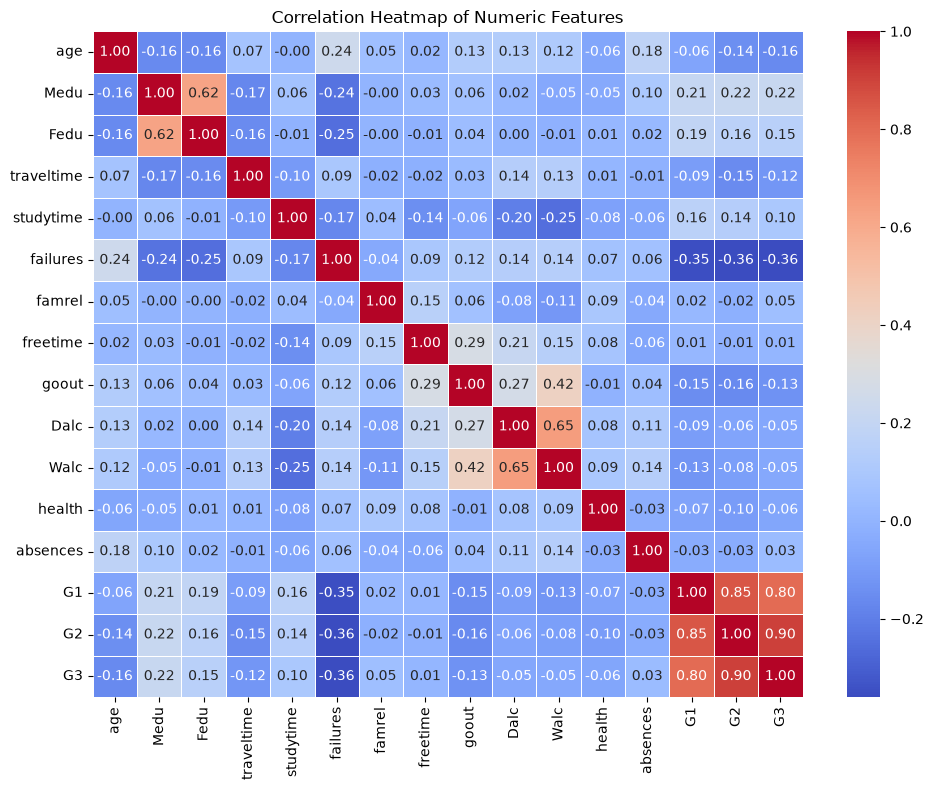

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Histogram: ดูการกระจายตัวของคะแนนสอบปลายภาค (G3)
plt.figure(figsize=(6, 4))
df['G3'].hist(bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.show()

# 2. Correlation Heatmap: ดูความสัมพันธ์ของคอลัมน์ที่เป็นตัวเลข
plt.figure(figsize=(10, 8))
# คัดเลือกเฉพาะคอลัมน์ที่เป็นตัวเลขมาหาความสัมพันธ์
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

## Part 3: Data Cleaning

In [4]:
# 1. เช็กความพร้อมและทำซ้ำเพื่อลบข้อมูล (Duplicate Removal)
print(f"จำนวนข้อมูลซ้ำก่อนตรวจสอบ: {df.duplicated().sum()} แถว")
df = df.drop_duplicates()  # คำสั่งลบแถวที่ซ้ำซ้อนออก
print(f"จำนวนข้อมูลซ้ำหลังจัดการ: {df.duplicated().sum()} แถว")
print("\n" + "="*50 + "\n")

# 2. จำลองแก้ไขตัวสะกดที่ผิด (Incorrect Data Correction)
# สมมติว่ามีโรงเรียนสะกดผิดจาก 'GP' เป็น 'G.P.' เราจะใช้คำสั่ง replace ในการคลีน
df['school'] = df['school'].replace('G.P.', 'GP')

# 3. ตรวจเช็กและจัดการค่าที่หายไป (Missing Value Handling)
# เนื่องจากข้อมูลจริงไม่มีค่าว่าง เราจะจำลองการเติมข้อมูลด้วยค่าเฉลี่ย/มัธยฐานตามทฤษฎีในสไลด์เรียน
# หากมีค่าว่างในคอลัมน์ G3 (คะแนนปลายภาค) จะเติมด้วยมัธยฐาน (Median)
df['G3'] = df['G3'].fillna(df['G3'].median())

# 4. แปลงประเภทข้อมูล (Data Type Conversion)
# แปลงคอลัมน์อายุ (age) ให้เป็นเลขฐาน int64 ให้สมบูรณ์
df['age'] = df['age'].astype('int64')

# 5. เปรียบเทียบค่าสถิติก่อน-หลัง (Compare Mean & Median) 
# สรุปค่าสถิติหลักของคะแนนปลายภาค (G3) ส่งท้ายกระบวนการคลีน
print("--- สรุปผลลัพธ์คะแนน G3 หลังทำ Data Cleaning ---")
print(f"ค่าเฉลี่ย (Mean): {df['G3'].mean():.2f}")
print(f"ค่ามัธยฐาน (Median): {df['G3'].median():.2f}")

จำนวนข้อมูลซ้ำก่อนตรวจสอบ: 0 แถว
จำนวนข้อมูลซ้ำหลังจัดการ: 0 แถว


--- สรุปผลลัพธ์คะแนน G3 หลังทำ Data Cleaning ---
ค่าเฉลี่ย (Mean): 10.42
ค่ามัธยฐาน (Median): 11.00


## Part 4: Feature Engineering

In [5]:
from sklearn.preprocessing import LabelEncoder

# 1. Label Encoding: แปลงคอลัมน์ที่มี 2 กลุ่ม หรือข้อมูลที่มีลำดับขั้น
# ในข้อมูลนี้ คอลัมน์ 'sex' มีแค่ F กับ M และ 'schoolsup' (การสนับสนุนจากโรงเรียน) มีแค่ yes กับ no
le = LabelEncoder()
df['sex_encoded'] = le.fit_transform(df['sex'])
df['schoolsup_encoded'] = le.fit_transform(df['schoolsup'])

# 2. One-Hot Encoding: แปลงคอลัมน์ตัวหนังสือทั่วไป โดยแตกออกเป็นคอลัมน์ย่อย 0 กับ 1
# ในข้อมูลนี้ คอลัมน์ 'Mjob' (อาชีพแม่) มีหลายกลุ่ม เช่น teacher, health, services, at_home, other
# เราจะใช้ pd.get_dummies เพื่อทำการ One-Hot เฉพาะคอลัมน์ Mjob
df_final = pd.get_dummies(df, columns=['Mjob'], prefix='Mjob', dtype=int)

# 3. แสดงผลคอลัมน์ใหม่ๆ ที่เราเพิ่งทำ Encoding เสร็จขึ้นมาเช็กดู
print("--- ตัวอย่างข้อมูลหลังทำ Feature Engineering ---")
# เลือกดึงบางคอลัมน์ที่แปลงแล้วมาโชว์เพื่อความดูง่าย
preview_cols = ['sex', 'sex_encoded', 'schoolsup', 'schoolsup_encoded'] + [col for col in df_final.columns if 'Mjob_' in col]
df_final[preview_cols].head()

--- ตัวอย่างข้อมูลหลังทำ Feature Engineering ---


,sex,sex_encoded,schoolsup,schoolsup_encoded,Mjob_at_home,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher
0,F,0,yes,1,1,0,0,0,0
1,F,0,no,0,1,0,0,0,0
2,F,0,yes,1,1,0,0,0,0
3,F,0,no,0,0,1,0,0,0
4,F,0,no,0,0,0,1,0,0
